# 10 - Market Access Analysis

## Purpose

Explore how HealthSynth simulates a change in pharmaceutical market access.

This notebook demonstrates how:

- a product behaves before an access event
- improved access changes its competitive opportunity
- market share shifts after the access date
- competing products lose some share through normalization
- prescription allocation changes downstream
- total monthly market demand remains fully reconciled

The objective is to understand market access as a commercial modifier rather than as a direct prescription adjustment.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_market_access.yaml",
    output_dir="../output/market_access_analysis",
)

In [3]:
products = datasets["product"]
market_share = datasets["market_share"]
prescriptions = datasets["prescriptions"]
market_demand = datasets["market_demand"]
call_activity = datasets["call_activity"]
promotion_effect = datasets["promotion_effect"]

## The Commercial Scenario

The simulated oncology market contains three established products.

Tumora receives improved market access in January 2024.

This may represent a formulary improvement, broader reimbursement, preferred status, or fewer prescribing restrictions.

The scenario follows this commercial chain:

```text
Market Access Change
        ↓
Competitive Opportunity Changes
        ↓
Adjusted Market Share Changes
        ↓
Product Demand Allocation Changes
        ↓
Generated Prescriptions Change
```

Nothing about the underlying market demand is changed directly.

The access event affects how much of that market each product can capture.

In [4]:
product_columns = [
    "product_id",
    "product_name",
    "manufacturer",
    "brand_type",
    "launch_date",
    "baseline_market_share",
    "market_access_date",
    "market_access_factor",
]

products[product_columns]

,product_id,product_name,manufacturer,brand_type,launch_date,baseline_market_share,market_access_date,market_access_factor
0,P001,OncoNova,NVA Pharma,Innovator,2021-01-01,0.5,NaN,NaN
1,P002,Tumora,Helix Therapeutics,Competitor,2021-01-01,0.3,2024-01-01,1.25
2,P003,Immunex,Apex Oncology,Competitor,2021-01-01,0.2,NaN,NaN


## Understanding the Market Access Configuration

The access product contains two scenario fields:

- `market_access_date` identifies when the access change takes effect.
- `market_access_factor` modifies the product's competitive strength from that month onward.

For example:

```yaml
market_access_date: "2024-01-01"
market_access_factor: 1.25
```

Interpretation:

- Before January 2024, the product uses a factor of `1.0`.
- From January 2024 onward, its competitive score is multiplied by `1.25`.

A factor:

- above `1.0` represents improved access
- below `1.0` represents restricted access
- equal to `1.0` represents no access effect

The factor does not directly set market share or prescriptions. It changes competitive opportunity before market shares are normalized.

In [5]:
market_share["month"] = pd.to_datetime(
    market_share["month"]
)

prescriptions["rx_date"] = pd.to_datetime(
    prescriptions["rx_date"]
)

market_demand["month"] = pd.to_datetime(
    market_demand["month"]
)

products["market_access_date"] = pd.to_datetime(
    products["market_access_date"],
    errors="coerce",
)

access_product = products[
    products["market_access_date"].notna()
].iloc[0]

access_product_id = access_product["product_id"]
access_product_name = access_product["product_name"]
access_date = access_product["market_access_date"]

access_product[
    [
        "product_id",
        "product_name",
        "market_access_date",
        "market_access_factor",
    ]
]

product_id                             P002
product_name                         Tumora
market_access_date      2024-01-01 00:00:00
market_access_factor                   1.25
Name: 1, dtype: object

## Access Factor Before and After the Event

Before the configured access date, the product should remain unaffected:

```text
Market access factor = 1.0
```

From the access month onward:

```text
Market access factor = configured value
```

The first HealthSynth implementation treats market access as an immediate step change.

This is suitable for events such as a formulary decision becoming effective on a specific date.

In [6]:
access_market_share = market_share[
    market_share["product_id"] == access_product_id
].copy()

access_market_share[
    [
        "month",
        "market_access_factor",
        "adjusted_market_share",
    ]
].head(18)

,month,market_access_factor,adjusted_market_share
1,2023-01-01,1.00,0.318964
4,2023-02-01,1.00,0.299580
7,2023-03-01,1.00,0.321824
10,2023-04-01,1.00,0.305321
13,2023-05-01,1.00,0.306820
16,2023-06-01,1.00,0.302092
19,2023-07-01,1.00,0.300917
22,2023-08-01,1.00,0.308402
25,2023-09-01,1.00,0.303566
28,2023-10-01,1.00,0.307940


In [7]:
pre_access = access_market_share[
    access_market_share["month"] < access_date
]

post_access = access_market_share[
    access_market_share["month"] >= access_date
]

assert (
    pre_access["market_access_factor"] == 1.0
).all()

assert (
    post_access["market_access_factor"]
    == access_product["market_access_factor"]
).all()

print("Market access factor changes from the configured access month.")

Market access factor changes from the configured access month.


## Visualizing the Market Access Event

Unlike launch adoption or LOE erosion, the access factor changes immediately in the current model.

This creates a clear commercial event date:

```text
Before access change: factor = 1.0
After access change:  factor = 1.25
```

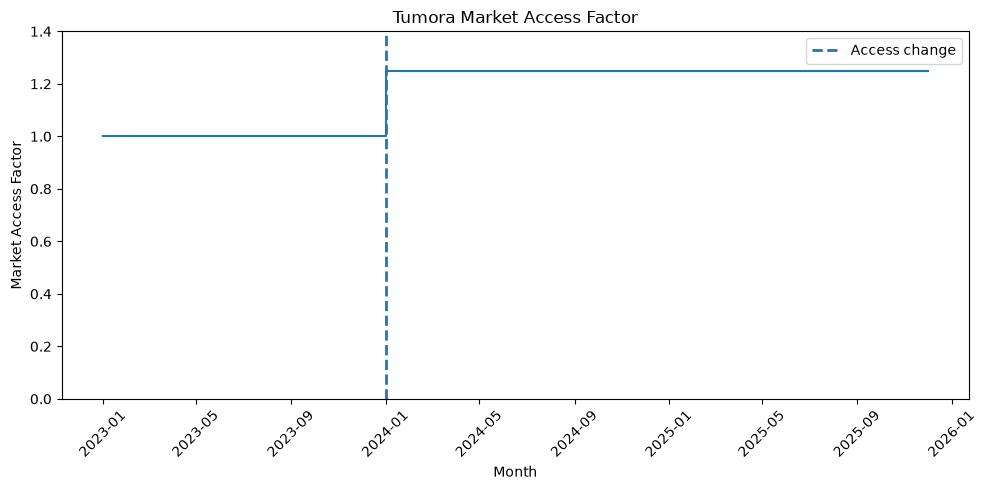

In [8]:
plt.figure(figsize=(10, 5))

plt.step(
    access_market_share["month"],
    access_market_share["market_access_factor"],
    where="post",
)

plt.axvline(
    access_date,
    linestyle="--",
    linewidth=2,
    label="Access change",
)

plt.title(f"{access_product_name} Market Access Factor")
plt.xlabel("Month")
plt.ylabel("Market Access Factor")
plt.ylim(0, access_market_share["market_access_factor"].max() + 0.15)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting the Access Factor

The access factor represents commercial opportunity rather than guaranteed performance.

Improved access may make it easier for healthcare providers to prescribe the product, but final market share still depends on:

- baseline competitive strength
- promotion
- competitor performance
- market noise
- normalization across all products

This is why a factor of `1.25` does not translate directly into a 25% increase in market share.

## Market Share Response

Market access affects the product's competitive score before market shares are normalized.

The calculation can be understood as:

```text
Baseline Score
        +
Promotion Effect
        +
Noise
        ↓
Apply Adoption and LOE Effects
        ↓
Apply Market Access Factor
        ↓
Normalize Across Products
        ↓
Adjusted Market Share
```

When Tumora receives improved access, it should gain share while the other products give up some of the market.

In [9]:
market_share_named = market_share.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

market_share_plot = market_share_named.pivot(
    index="month",
    columns="product_name",
    values="adjusted_market_share",
)

market_share_plot.head()

product_name,Immunex,OncoNova,Tumora
month,,,
2023-01-01,0.221927,0.459109,0.318964
2023-02-01,0.225133,0.475287,0.299580
2023-03-01,0.224102,0.454074,0.321824
2023-04-01,0.228313,0.466366,0.305321
2023-05-01,0.230566,0.462613,0.306820


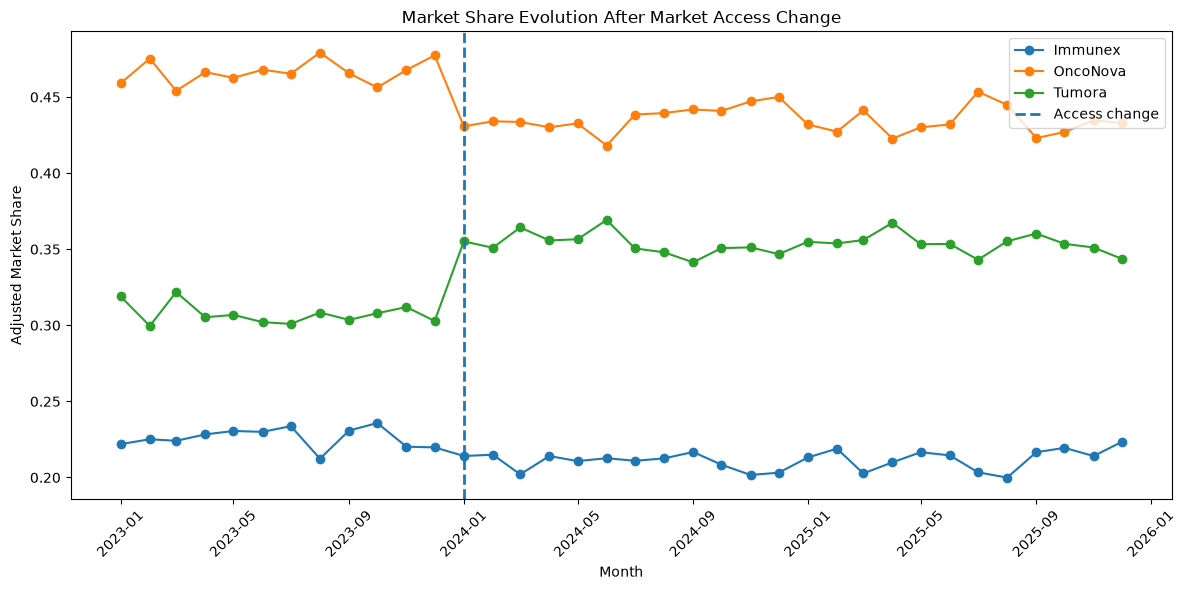

In [10]:
plt.figure(figsize=(12, 6))

for product_name in market_share_plot.columns:
    plt.plot(
        market_share_plot.index,
        market_share_plot[product_name],
        marker="o",
        label=product_name,
    )

plt.axvline(
    access_date,
    linestyle="--",
    linewidth=2,
    label="Access change",
)

plt.title("Market Share Evolution After Market Access Change")
plt.xlabel("Month")
plt.ylabel("Adjusted Market Share")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations

The market-share trend should show:

- Tumora remaining relatively stable before January 2024
- a visible increase after improved access takes effect
- competing products giving up some share through normalization
- monthly market shares continuing to sum to 100%

Month-to-month values may still fluctuate because promotion and market noise continue to affect all products.

In [11]:
comparison_months = [
    access_date - pd.DateOffset(months=1),
    access_date,
    access_date + pd.DateOffset(months=6),
]

share_comparison = (
    market_share_named[
        market_share_named["month"].isin(
            comparison_months
        )
    ]
    .pivot(
        index="product_name",
        columns="month",
        values="adjusted_market_share",
    )
)

share_comparison

month,2023-12-01,2024-01-01,2024-07-01
product_name,,,
Immunex,0.219792,0.214127,0.210981
OncoNova,0.477372,0.430744,0.438480
Tumora,0.302836,0.355129,0.350539


## Measuring the Access Impact

A single month can be affected by random market variation.

For that reason, comparing average share before and after the access event is often more informative than comparing only two individual months.

In [12]:
access_product_share = access_market_share[
    [
        "month",
        "adjusted_market_share",
    ]
].copy()

pre_access_average = access_product_share[
    access_product_share["month"] < access_date
]["adjusted_market_share"].mean()

post_access_average = access_product_share[
    access_product_share["month"] >= access_date
]["adjusted_market_share"].mean()

access_summary = pd.DataFrame(
    {
        "period": [
            "Before access change",
            "After access change",
        ],
        "average_market_share": [
            pre_access_average,
            post_access_average,
        ],
    }
)

access_summary

,period,average_market_share
0,Before access change,0.307521
1,After access change,0.353599


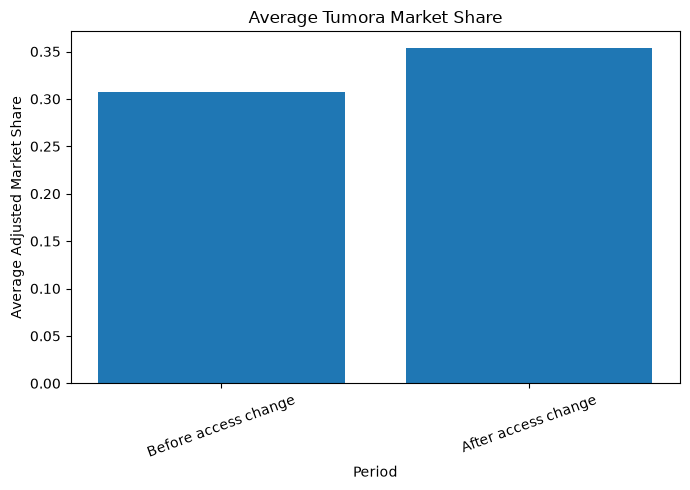

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    access_summary["period"],
    access_summary["average_market_share"],
)

plt.title(f"Average {access_product_name} Market Share")
plt.xlabel("Period")
plt.ylabel("Average Adjusted Market Share")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Improved Access and Competitive Outcome

The post-access average should be higher than the pre-access average.

This confirms that the access event creates a sustained change in competitive position rather than only a one-month fluctuation.

The final share increase will normally be smaller than the increase in the access factor because all products are normalized into the same 100% market.

In [14]:
assert post_access_average > pre_access_average

print(
    f"Average {access_product_name} market share increased "
    "after improved access."
)

Average Tumora market share increased after improved access.


## Prescription Impact

Market access does not directly add prescription records.

The downstream flow is:

```text
Improved Access
        ↓
Higher Adjusted Market Share
        ↓
Larger Share of Monthly Market Demand
        ↓
Higher Product NRx Allocation
```

Absolute NRx can still fluctuate because total monthly market demand changes with growth, seasonality, and noise.

In [15]:
rx_named = prescriptions.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

monthly_rx = (
    rx_named.groupby(
        [
            "rx_date",
            "product_name",
        ]
    )["nrx"]
    .sum()
    .reset_index()
)

monthly_rx.head()

,rx_date,product_name,nrx
0,2023-01-01,Immunex,150
1,2023-01-01,OncoNova,308
2,2023-01-01,Tumora,205
3,2023-02-01,Immunex,161
4,2023-02-01,OncoNova,338


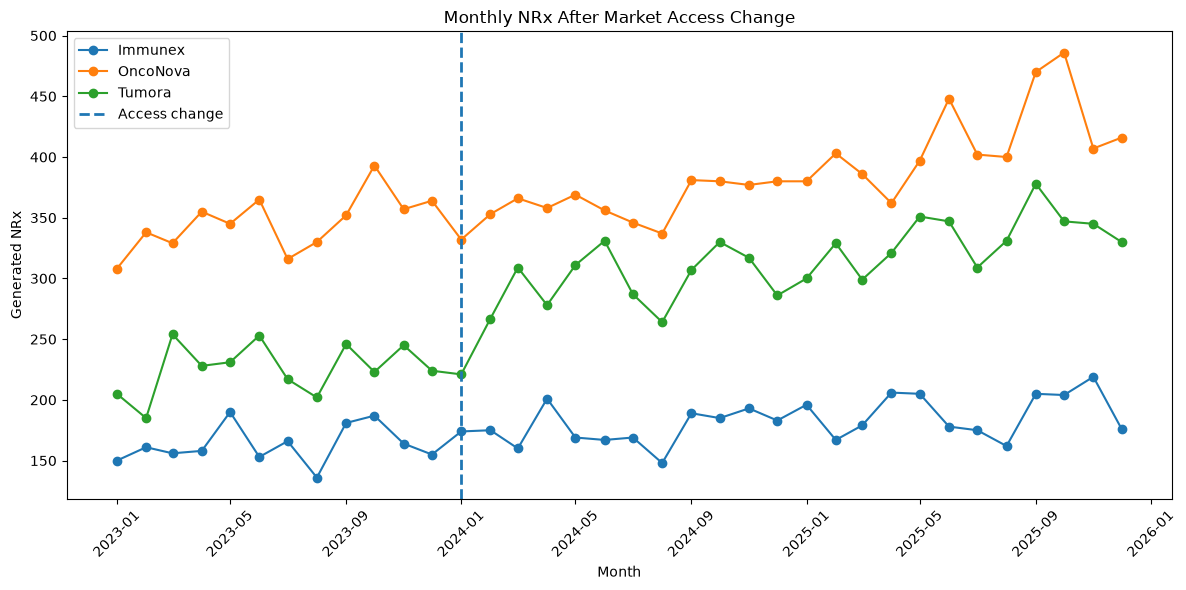

In [16]:
rx_plot = monthly_rx.pivot(
    index="rx_date",
    columns="product_name",
    values="nrx",
)

plt.figure(figsize=(12, 6))

for product_name in rx_plot.columns:
    plt.plot(
        rx_plot.index,
        rx_plot[product_name],
        marker="o",
        label=product_name,
    )

plt.axvline(
    access_date,
    linestyle="--",
    linewidth=2,
    label="Access change",
)

plt.title("Monthly NRx After Market Access Change")
plt.xlabel("Month")
plt.ylabel("Generated NRx")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Market Share and Absolute NRx

Improved access should increase the product's average prescription allocation.

However, NRx may not rise in every individual month because:

- total market demand changes
- seasonality affects market volume
- promotion continues to vary
- competitors continue to move

Commercial performance should therefore be evaluated using both market share and absolute prescription volume.

In [17]:
access_product_rx = monthly_rx[
    monthly_rx["product_name"] == access_product_name
].copy()

pre_access_rx_average = access_product_rx[
    access_product_rx["rx_date"] < access_date
]["nrx"].mean()

post_access_rx_average = access_product_rx[
    access_product_rx["rx_date"] >= access_date
]["nrx"].mean()

rx_access_summary = pd.DataFrame(
    {
        "period": [
            "Before access change",
            "After access change",
        ],
        "average_monthly_nrx": [
            pre_access_rx_average,
            post_access_rx_average,
        ],
    }
)

rx_access_summary

,period,average_monthly_nrx
0,Before access change,226.083333
1,After access change,312.291667


## Demand Reconciliation

The market access event changes how demand is distributed among products.

It does not change the upstream total market volume.

For every month:

```text
Total Generated NRx
        =
Simulated Market NRx
```

In [18]:
monthly_generated_nrx = (
    prescriptions.groupby("rx_date")["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

monthly_generated_nrx["month"] = pd.to_datetime(
    monthly_generated_nrx["month"]
)

demand_reconciliation = market_demand[
    [
        "month",
        "market_nrx",
    ]
].merge(
    monthly_generated_nrx,
    on="month",
    how="left",
)

demand_reconciliation["difference"] = (
    demand_reconciliation["generated_nrx"]
    - demand_reconciliation["market_nrx"]
)

demand_reconciliation.head()

,month,market_nrx,generated_nrx,difference
0,2023-01-01,663,663,0
1,2023-02-01,684,684,0
2,2023-03-01,739,739,0
3,2023-04-01,741,741,0
4,2023-05-01,766,766,0


In [19]:
assert (
    demand_reconciliation["difference"] == 0
).all()

print(
    "Monthly generated NRx reconciles exactly "
    "with simulated market demand."
)

Monthly generated NRx reconciles exactly with simulated market demand.


> **Business Insight**
>
> Market access changes opportunity, not guaranteed performance.
>
> Analysts should evaluate:
>
> - the effective date of the access change
> - the magnitude of the access factor
> - sustained market-share movement
> - prescription allocation before and after the event
> - competitor impact
> - whether market growth is amplifying the apparent benefit
>
> Improved access can create a meaningful competitive advantage without making the product the market leader.

## Key Takeaways

- Market access is configured at the product level.
- The access factor remains `1.0` before the event date.
- Improved access uses a factor above `1.0`.
- Restricted access can be represented using a factor below `1.0`.
- The factor changes competitive strength rather than directly setting market share.
- Market shares are normalized across all products.
- Prescription changes emerge from market-share allocation.
- Absolute NRx may still fluctuate despite improved access.
- Total generated NRx remains fully reconciled with market demand.

This scenario completes the first set of flagship HealthSynth commercial events:

```text
New Product Launch
Loss of Exclusivity
Competitor Launch
Market Access
```

Together, they demonstrate HealthSynth's central philosophy:

```text
Define a commercial world
        ↓
Introduce a commercial event
        ↓
Simulate market response
        ↓
Generate internally consistent datasets
        ↓
Analyse the resulting outcomes
```